### 1. Import Libraries 

In [1]:
# Load Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset & Overview

In [2]:
# Convert relative path safely
raw_path = ("../data/raw/train.csv")

# Load the dataset
df = pd.read_csv(raw_path)

# Display the first few rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 3. Exploratary Data Analysis (EDA)

In [3]:
# Shape of the dataset
df.shape

(1460, 81)

In [4]:
# Display a concise summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

- Since the dataset contains 81 columns, the default ```df.info()``` output is difficult to interpret. A better approach is to split the columns into numerical and categorical groups.

In [5]:
# Separate feature types
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

print(f'Numerical columns:{len(num_cols)}\n{num_cols}')
print(f'\nCategorical columns:{len(cat_cols)}\n{cat_cols}')

Numerical columns:38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

Categorical columns:43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtF

In [6]:
# Show the stats of numerical features
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


##### Missing Values

In [7]:
# Count missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Columns with missing values: {len(missing)}')
missing.head(15)

Columns with missing values: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
dtype: int64

- Total 19 columns contains missing values. Highly missing values features are ``PoolQC``,``MiscFeature``, ``Alley``, ``Fence``, ``MasVnrType``, ``FireplaceQu``, ``LotFrontage``, which means they can be dropped later stages. 
- Some feaures have same missing values. This means they are independent on each other. Suppose if some property does not have Garage which means all the values related to columns will be missing. 

In [8]:
# Numerical columns missing values
print(df[num_cols].isnull().sum()[df[num_cols].isnull().sum() > 0])

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


- The LotFrontage column has the highest number of missing values (LotFrontage: linear feet of street connected to the property).
- The GarageYrBlt column also has missing values, which depend on the presence of a garage.

In [9]:
# Categorical columns with missing values
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


- As already confirmed that several categorical columns contain a large number of missing values.
- Columns such as ``PoolQC``, ``MiscFeature``, ``Alley``, and ``Fence``have very high missing counts, indicating that these features are not available for most properties.
- Basement-related columns ``BsmtQual``, ``BsmtCond``, ``BsmtExposure``, ``BsmtFinType1``, ``BsmtFinType2`` and garage-related columns ``GarageType``, ``GarageFinish``, ``GarageQual``, ``GarageCond`` also have missing values, likely because some houses lack a basement or garage.

##### Univariate Analysis

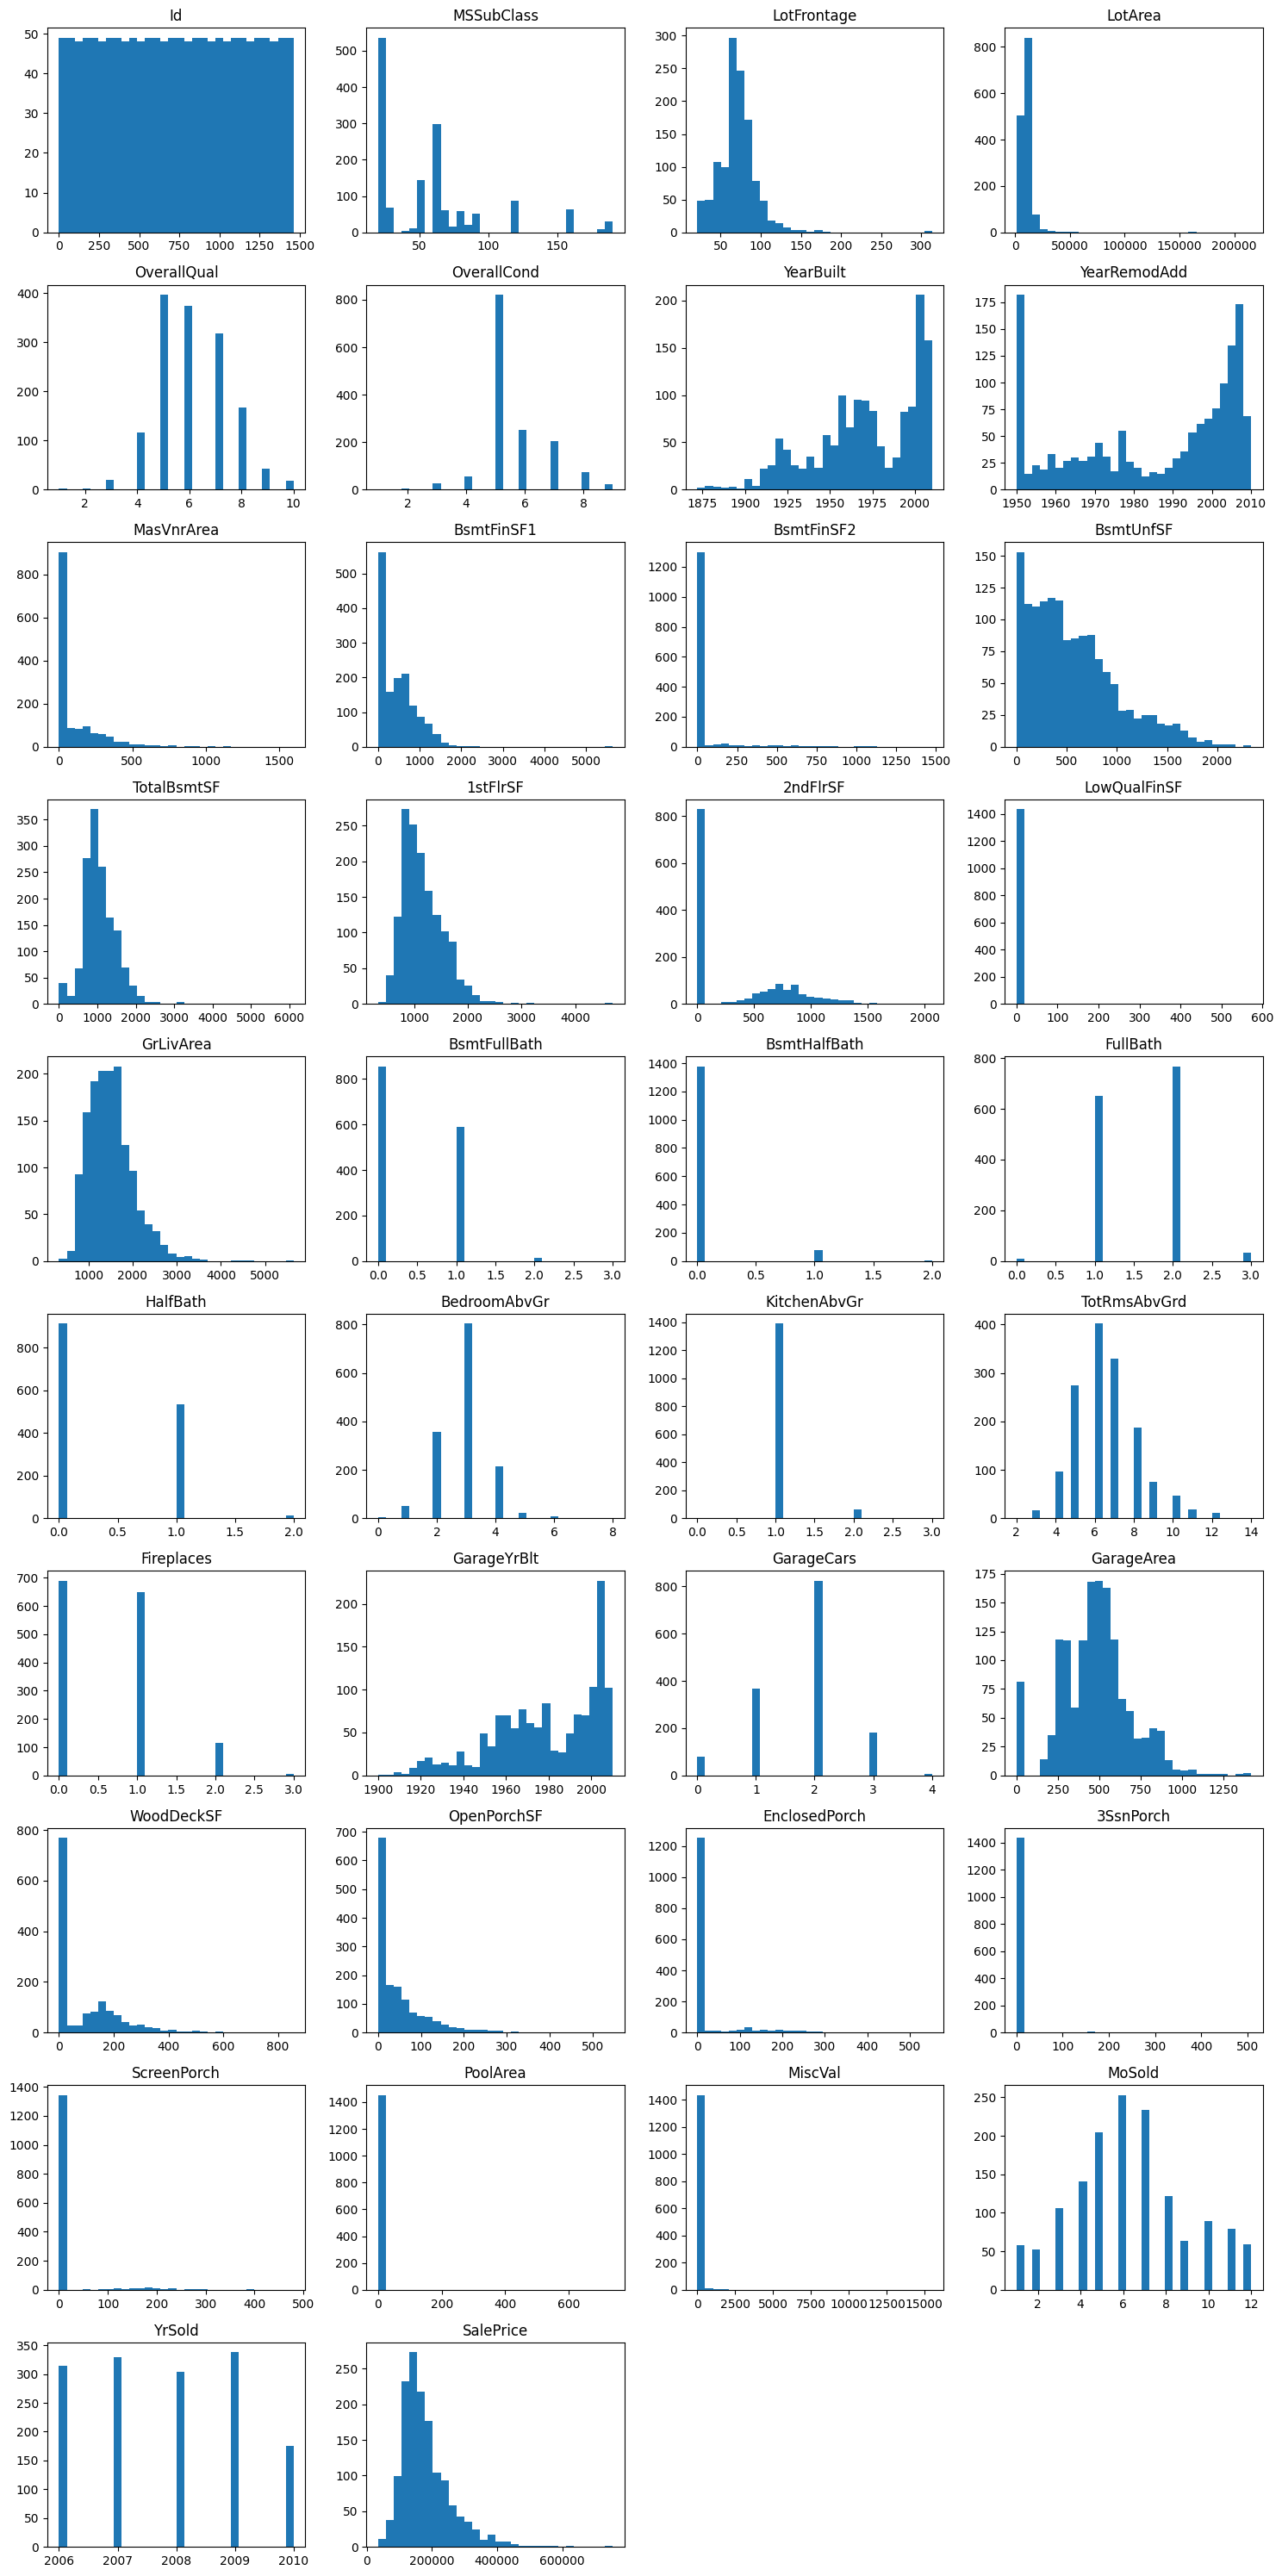

In [10]:
# Display the numerical columns
plt.figure(figsize=(15, 30))
for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 4, i)       
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

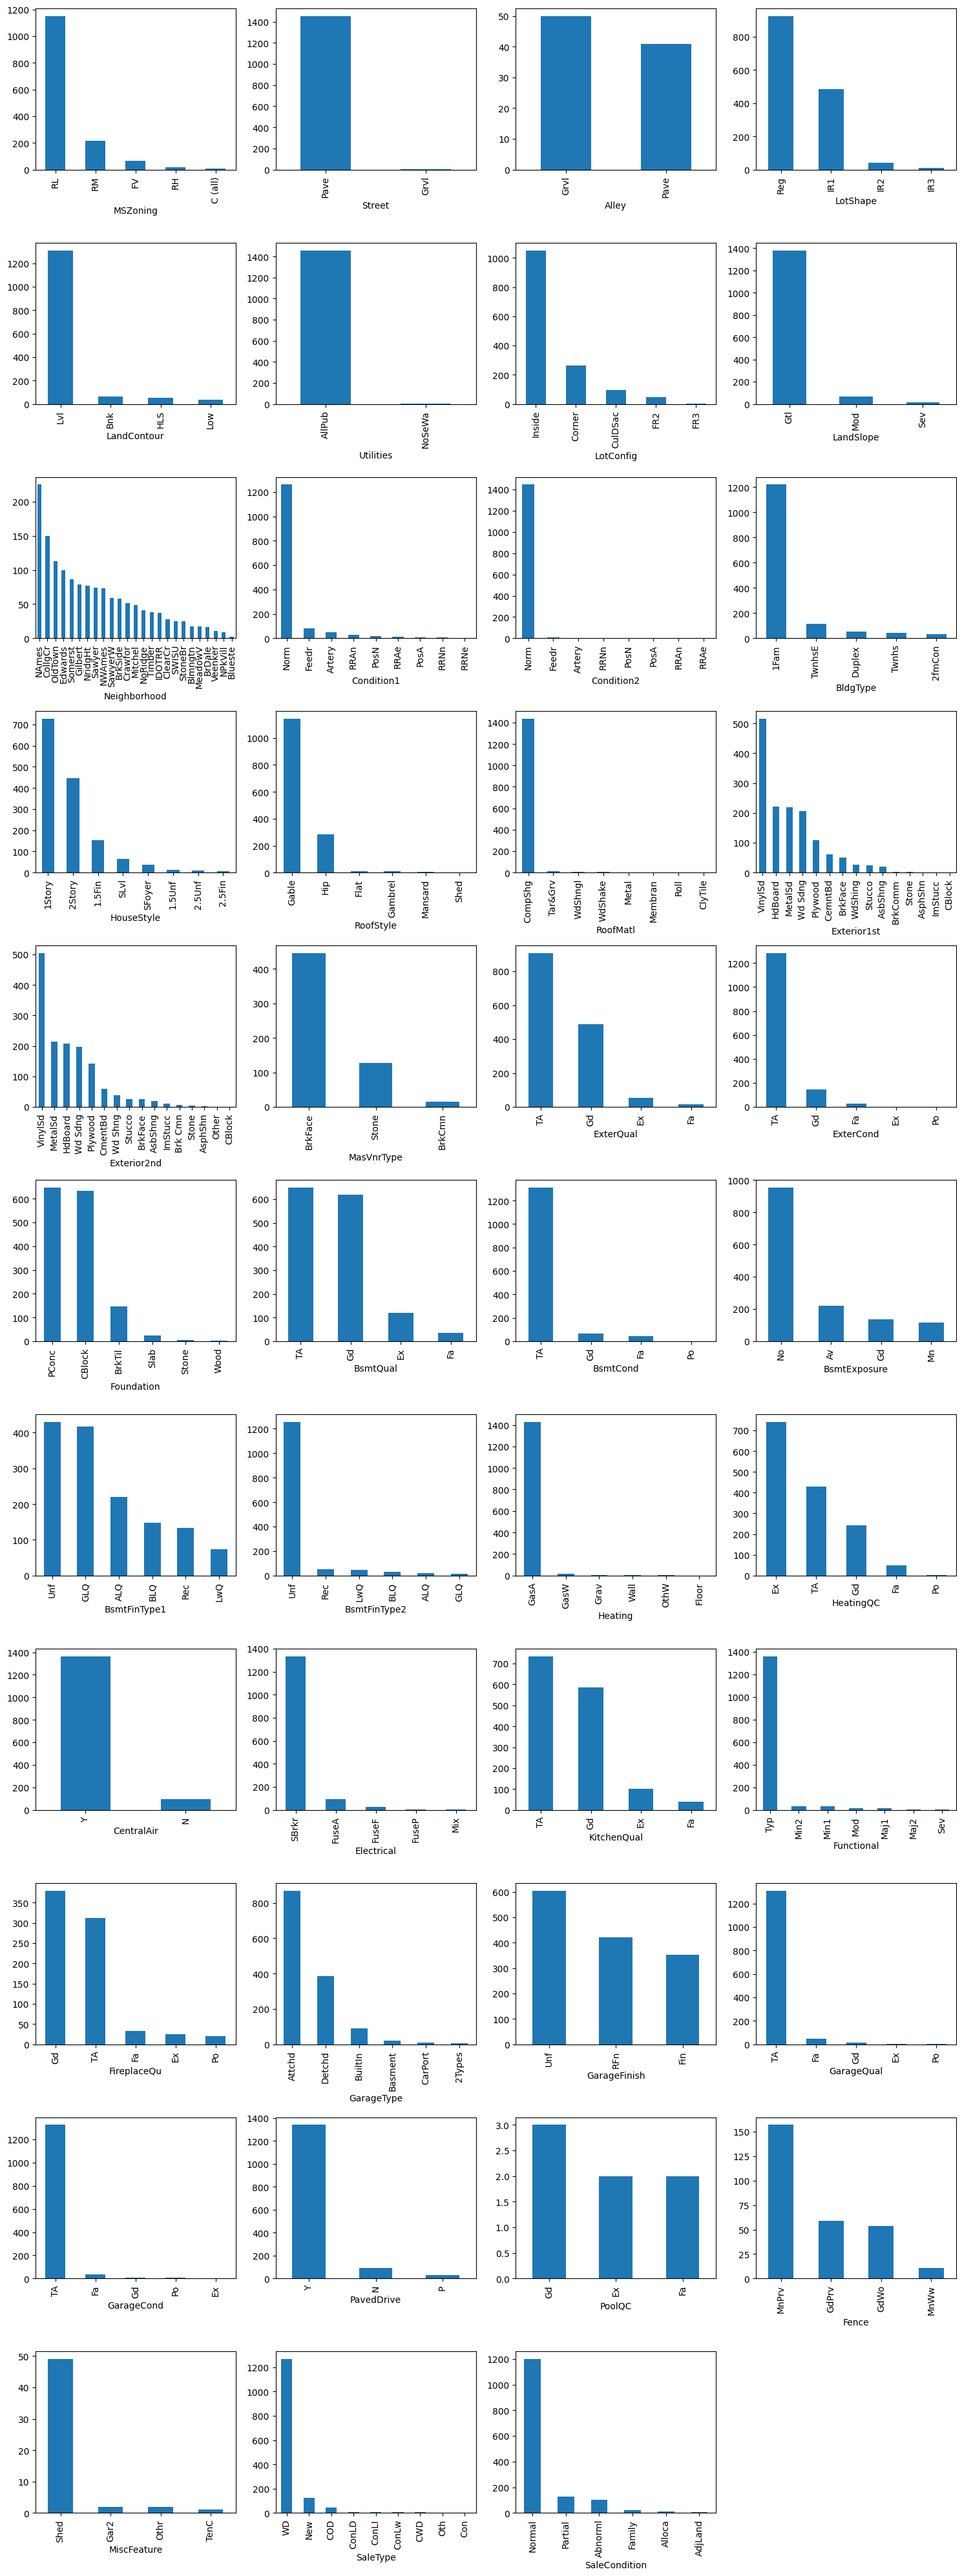

In [11]:
# Display categorical  columns
plt.figure(figsize=(15, 40))

for i,col in enumerate(cat_cols, 1):
    plt.subplot(11, 4, i)
    df[col].value_counts().plot(kind='bar')
    # plt.title(col)
plt.tight_layout()
plt.show()

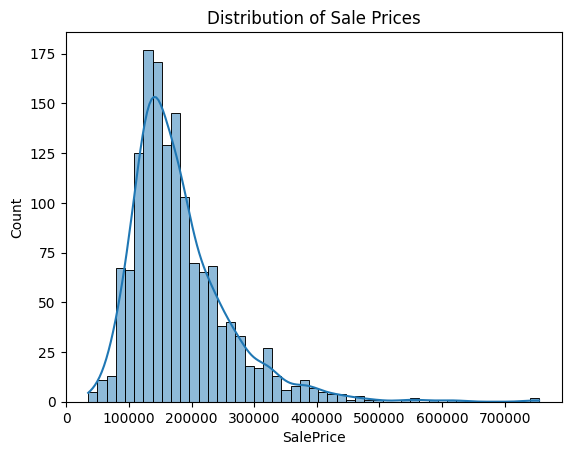

In [12]:
# Understand our target feature distribution
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.show()

In [13]:
print(df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


##### Bivariate Analysis

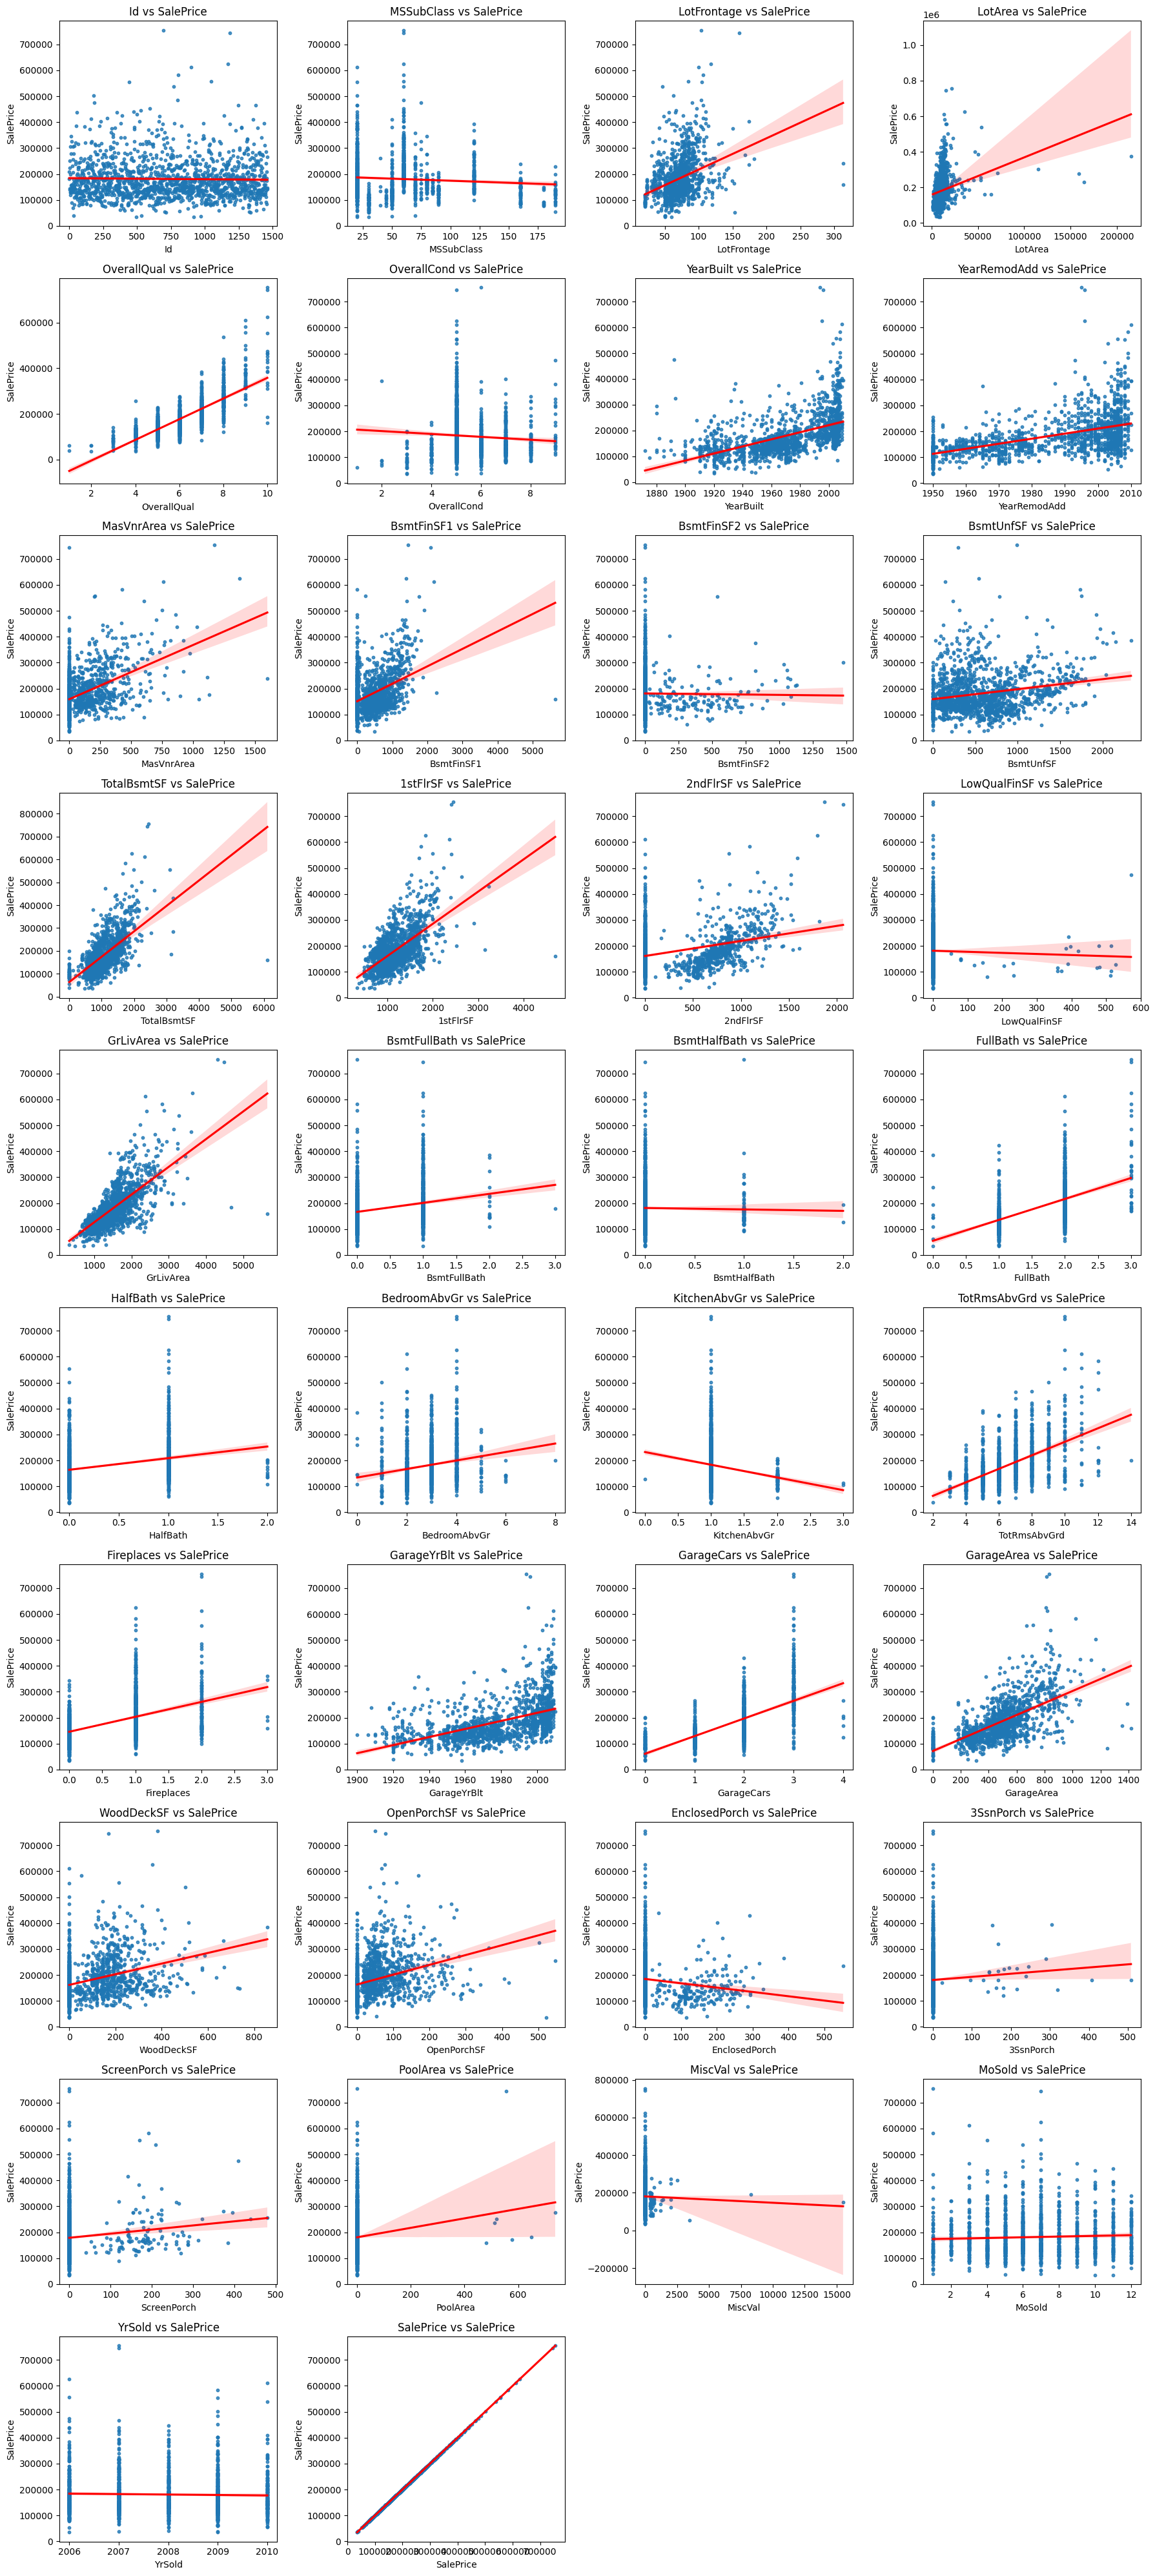

In [14]:
plt.figure(figsize=(18, 40))

for i, col in enumerate(num_cols, 1):  # plot first 20 for clarity
    plt.subplot(10, 4, i)
    sns.regplot(x=df[col], y=df['SalePrice'], scatter_kws={'s':10}, line_kws={'color':'red'})
    plt.title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

In [15]:
# Compute correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)

# Get correlation values with SalePrice, sorted descending
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

# Display the correlations
saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

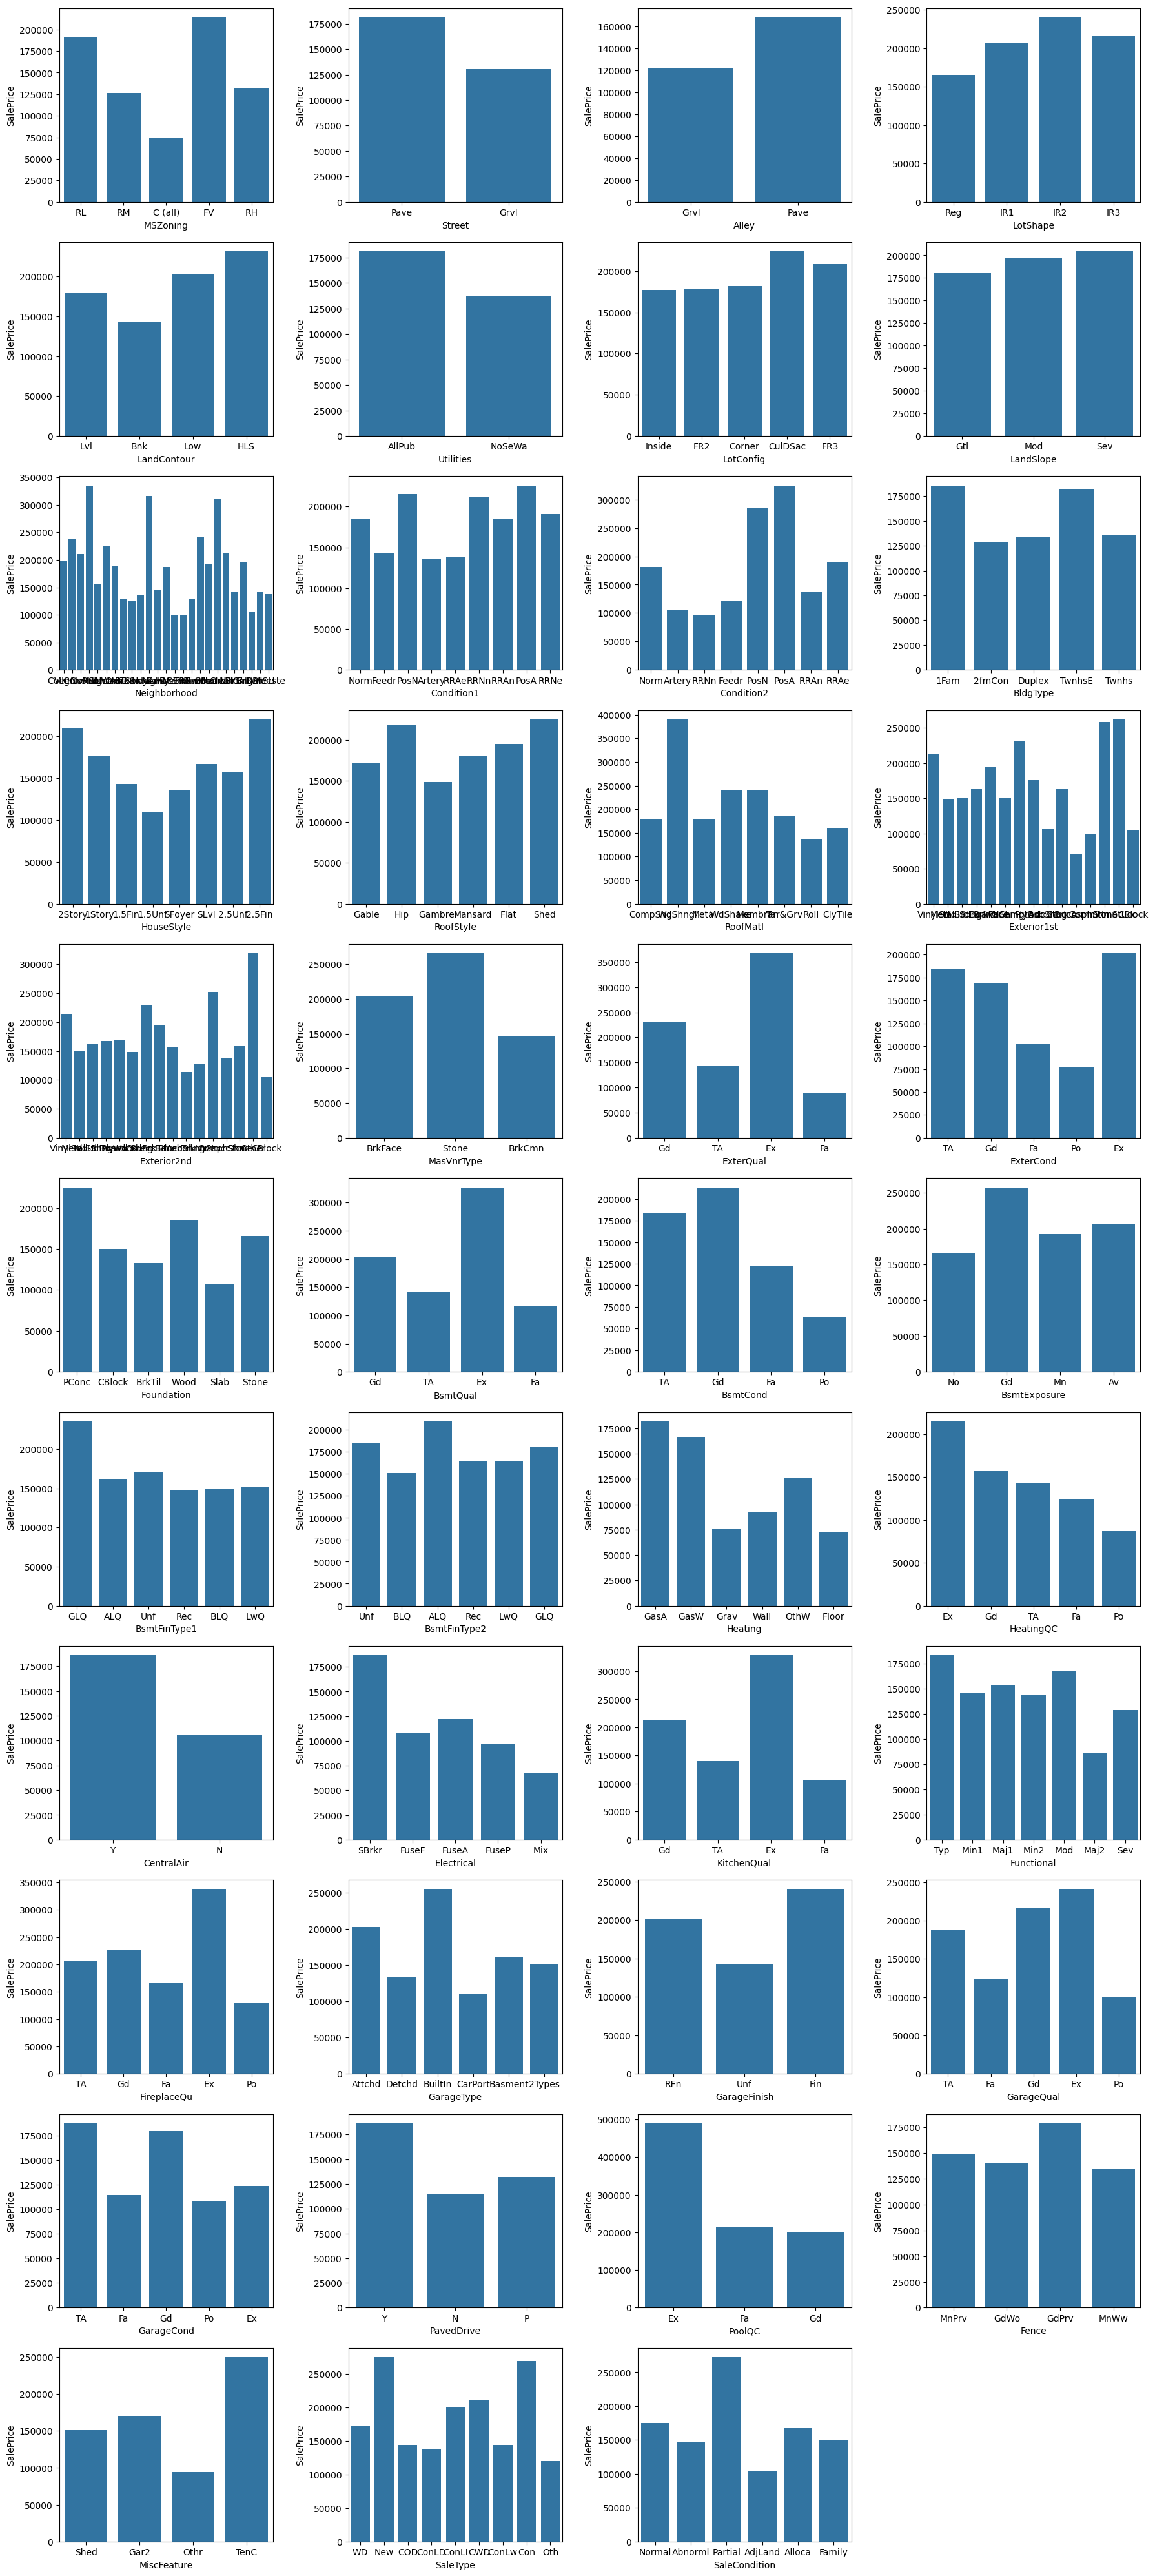

In [16]:
plt.figure(figsize=(18, 40))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(11, 4, i)
    sns.barplot(data=df, x=col, y='SalePrice', errorbar=None)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


Key EDA Insights:
- Dataset: 1460 rows × 81 columns.

- Numeric columns: 38, Categorical columns: 43

- SalePrice is right-skewed → log transform recommended

- Top correlated features: OverallQual, GrLivArea, GarageCars, TotalBsmtSF

- High missingness in PoolQC, Alley, Fence, MiscFeature, FireplaceQu

- Some missing numeric fields: LotFrontage, MasVnrArea, GarageYrBlt

- Houses with better quality (OverallQual) and more living area tend to be more expensive

---

### 4. Feature Engineering

Feature Engineering included:

- 4.1: Handling missing values

- 4.2: Encoding categorical variables

- 4.3: Log-transformation of skewed features

- 4.4: New feature creation (TotalSF, HouseAge, TotalBath, etc.)

- 4.5: Scaling numerical features

- 4.6: Removing outliers

- 4.7: Finalizing feature matrix for training

#### 4.1 Handling Missing Values

**Numerical Features Treatment**

In [17]:
print("Missing Values in Numeric columns:")
print(df[num_cols].isnull().sum()[df[num_cols].isnull().sum() > 0])

print("\nMissing Values in Categorical columns:")
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])

Missing Values in Numeric columns:
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

Missing Values in Categorical columns:
Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


**LotFrontag**

- LotFrontage: Linear feet of street connected to property

In [18]:
df['LotFrontage'].describe() 

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [19]:
df[df['LotFrontage'].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
12,13,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000
14,15,20,RL,NaN,10920,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,157000
16,17,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
24,25,20,RL,NaN,8246,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,1430,20,RL,NaN,12546,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2007,WD,Normal,182900
1431,1432,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,143750
1441,1442,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,149300
1443,1444,30,RL,NaN,8854,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,121000


In [20]:
# Since it is area connected to street and it depends on the neighborhood'
df[df['LotFrontage'].isnull()][['LotFrontage', 'Neighborhood']]

,LotFrontage,Neighborhood
7,NaN,NWAmes
12,NaN,Sawyer
14,NaN,NAmes
16,NaN,NAmes
24,NaN,Sawyer
...,...,...
1429,NaN,NWAmes
1431,NaN,NPkVill
1441,NaN,CollgCr
1443,NaN,BrkSide


In [21]:
df[df['LotFrontage'].isnull()].groupby('Neighborhood')['LotFrontage'].size()

Neighborhood
Blmngtn     3
BrkSide     7
ClearCr    15
CollgCr    24
Crawfor    10
Edwards     8
Gilbert    30
IDOTRR      3
MeadowV     2
Mitchel    13
NAmes      39
NPkVill     2
NWAmes     28
NoRidge     8
NridgHt     1
OldTown     4
SWISU       2
Sawyer     26
SawyerW     9
Somerst     8
StoneBr     5
Timber      8
Veenker     4
Name: LotFrontage, dtype: int64

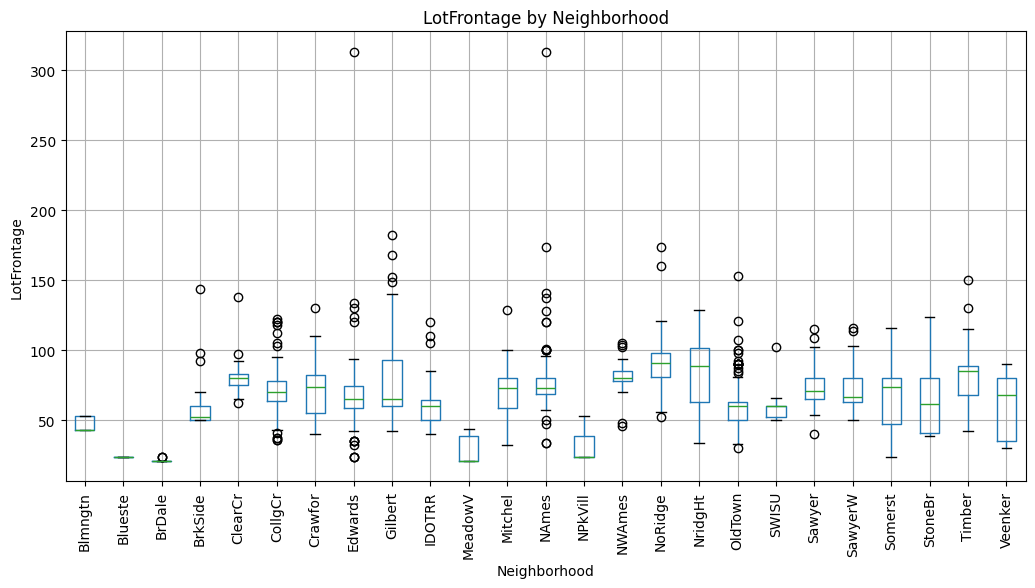

In [22]:
df.boxplot(column='LotFrontage', by='Neighborhood', rot=90, figsize=(12,6))
plt.title('LotFrontage by Neighborhood')
plt.suptitle('')
plt.xlabel('Neighborhood')
plt.ylabel('LotFrontage')
plt.show()

- The boxplot shows that LotFrontage values are very spread out in most neighborhoods. Many points lie far from the box, which means there are outliers.

- We will fill the missing LotFrontage values using the medianvalue of each neighborhood, because the median is not affected by outliers. After filling, we can check again to be sure the values look correct.

In [23]:
# Fill LotFrontage by neighborhood median
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

missing_val_lotfrontage=  df['LotFrontage'].isnull().sum()
print(missing_val_lotfrontage)

0


**MasVnrArea**

MasVnrArea — Masonry veneer area (in square feet). This represents the area of the exterior walls covered with brick or stone veneer on the house.

In [24]:
missing_val_masvnrarea= df['MasVnrArea'].isnull().sum()

print(missing_val_masvnrarea)

8


In [25]:
score_core= df[['MasVnrArea', 'SalePrice']].corr()
print(score_core)

            MasVnrArea  SalePrice
MasVnrArea    1.000000   0.477493
SalePrice     0.477493   1.000000


In [26]:
df['MasVnrArea'].describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

- The MasVnrArea column has minimum values of 0, indicating properties with no masonry veneer area.
- There is also a related categorical column, MasVnrType, which specifies the type of masonry veneer.

- Use MasVnrType along with MasVnrArea to handle missing or zero values appropriately.
- If MasVnrType is 'None', then a MasVnrArea of 0 is valid.
- Otherwise, verify or impute missing or zero values based on similar property records.

In [27]:
df['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [28]:
df[['MasVnrArea','MasVnrType']].head

<bound method NDFrame.head of       MasVnrArea MasVnrType
0          196.0    BrkFace
1            0.0        NaN
2          162.0    BrkFace
3            0.0        NaN
4          350.0    BrkFace
...          ...        ...
1455         0.0        NaN
1456       119.0      Stone
1457         0.0        NaN
1458         0.0        NaN
1459         0.0        NaN

[1460 rows x 2 columns]>

In [29]:
df['MasVnrArea'].fillna(0, inplace=True)

df['MasVnrType'].fillna("None", inplace=True)

C:\Users\harma\AppData\Local\Temp\ipykernel_956\2491213417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MasVnrArea'].fillna(0, inplace=True)
C:\Users\harma\AppData\Local\Temp\ipykernel_956\2491213417.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [30]:
missing_val_masvnrarea= df['MasVnrArea'].isnull().sum()

print(missing_val_masvnrarea)

0


**GarageYrBLt**

In [31]:
df[df['GarageYrBlt'].isnull()].head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
39,40,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
78,79,90,RL,72.0,10778,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,136500
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
89,90,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600


<Axes: xlabel='GarageYrBlt', ylabel='SalePrice'>

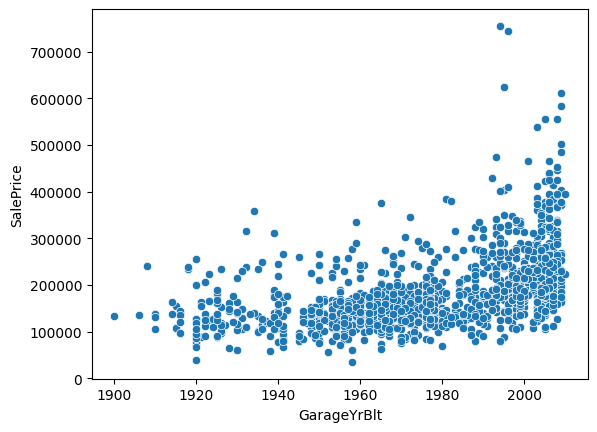

In [32]:
sns.scatterplot(x="GarageYrBlt", y="SalePrice", data=df)

In [33]:
score_core= df[['GarageYrBlt', 'SalePrice']].corr()
print(score_core)

             GarageYrBlt  SalePrice
GarageYrBlt     1.000000   0.486362
SalePrice       0.486362   1.000000


In [34]:
df['GarageYrBlt'].describe()

count    1379.000000
mean     1978.506164
std        24.689725
min      1900.000000
25%      1961.000000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

In [35]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [36]:
df[['GarageYrBlt','YearBuilt']].isnull().sum()

GarageYrBlt    0
YearBuilt      0
dtype: int64

**Treating Categorical Missing Values** 

In [37]:
print("\nMissing Values in Categorical columns:")
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])


Missing Values in Categorical columns:
Alley           1369
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


Garage-related features such as ``GarageType, GarageFinish, GarageQual, and GarageCond`` were treated based on the presence of a garage.
For houses without a garage (``GarageYrBlt = 0``), all these categorical values were set to "None" to maintain consistency.
Any remaining missing values were also filled with "None".

In [38]:
garage_feat = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_feat:
    df.loc[df['GarageYrBlt'] == 0, col] = 'None'

Drops: COlumsn

#### 4.2 Drop Columns

In [39]:
print("\nMissing Values in Categorical columns:")
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])


Missing Values in Categorical columns:
Alley           1369
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [40]:
drop_cols_list = ['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature', 'Electrical']

# Drop columns 
df= df.drop(columns=drop_cols_list)

# Remove the same names from the cat_cols
cat_cols= [col for col in cat_cols if col not in drop_cols_list]

print('\nMissing Values in Categorical columns:')
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])


Missing Values in Categorical columns:
BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
dtype: int64


- Basement-related categorical features were filled with "None" because missing values indicate that the house has no basement.

In [41]:
# Drop 'Id' column
df.drop(columns='Id', inplace=True)

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [42]:
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[bsmt_cols] = df[bsmt_cols].fillna("None")

In [43]:
print('\nMissing Values in dataset:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing Values in dataset:
Series([], dtype: int64)


In [44]:
# Display first few rows
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


#### 4.3 Data Type Conversion

``MSSubClass looks`` like a number, but it is not a numerical feature. It represents categories of house types, not a measurable quantity.

In [45]:
# Convert MSSubClass to category 
df['MSSubClass'] = df['MSSubClass'].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   category
 1   MSZoning       1460 non-null   object  
 2   LotFrontage    1460 non-null   float64 
 3   LotArea        1460 non-null   int64   
 4   Street         1460 non-null   object  
 5   LotShape       1460 non-null   object  
 6   LandContour    1460 non-null   object  
 7   Utilities      1460 non-null   object  
 8   LotConfig      1460 non-null   object  
 9   LandSlope      1460 non-null   object  
 10  Neighborhood   1460 non-null   object  
 11  Condition1     1460 non-null   object  
 12  Condition2     1460 non-null   object  
 13  BldgType       1460 non-null   object  
 14  HouseStyle     1460 non-null   object  
 15  OverallQual    1460 non-null   int64   
 16  OverallCond    1460 non-null   int64   
 17  YearBuilt      1460 non-null   in

### 5. Feature Transformation

#### 5.1 Orinal Columns Treatment

During the initial data overview and by reviewing the ``data_description.txt file``, I identified several ordinal columns features whose categories follow a natural order or rating scale. These include quality, condition, exposure, and finish-related attributes such as: ``ExterQual``, ``ExterCond``, ``BsmtQual``, ``BsmtCond``, ``smtExposure``, ``HeatingQC``, ``KitchenQual``, ``GarageQual``, ``GarageCond``, ``BsmtFinType1``, ``BsmtFinType2``, ``LotShape``, ``LandSlope``. These features require ordinal encoding rather than one-hot encoding to preserve their inherent ranking

In [46]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPor

In [47]:
# Ordinal column list
ordinal_cols = [
    'ExterQual','ExterCond',
    'BsmtQual','BsmtCond',
    'HeatingQC','KitchenQual',
    'GarageQual','GarageCond',
    'BsmtExposure','BsmtFinType1','BsmtFinType2',
    'LotShape','LandSlope',
    'Functional'
]

# Keep only columns that actually exist in df
ordinal_cols = [c for c in ordinal_cols if c in df.columns]

# Mapping dictionaries
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0, "NA": 0}
exposure_map = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0, "NA": 0}
bsmtfin_map = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0, "NA": 0}
lotshape_map = {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1}
landslope_map = {"Gtl": 3, "Mod": 2, "Sev": 1}
functional_map = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4,
                  "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}

# Full mapping dictionary
ordinal_mappings = {
    'ExterQual': quality_map,
    'ExterCond': quality_map,
    'BsmtQual': quality_map,
    'BsmtCond': quality_map,
    'HeatingQC': quality_map,
    'KitchenQual': quality_map,
    'GarageQual': quality_map,
    'GarageCond': quality_map,
    'BsmtExposure': exposure_map,
    'BsmtFinType1': bsmtfin_map,
    'BsmtFinType2': bsmtfin_map,
    'LotShape': lotshape_map,
    'LandSlope': landslope_map,
    'Functional': functional_map
}

# Apply encoding safely

for col in ordinal_cols:
    df[col] = df[col].map(ordinal_mappings[col])

# View the encoded ordinal columns
df[ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,GarageQual,GarageCond,BsmtExposure,BsmtFinType1,BsmtFinType2,LotShape,LandSlope,Functional
0,4,3,4,3,5,4,3,3,1,6,1,4,3,7
1,3,3,4,3,5,3,3,3,4,5,1,4,3,7
2,4,3,4,3,5,4,3,3,2,6,1,3,3,7
3,3,3,3,4,4,4,3,3,1,5,1,3,3,7
4,4,3,4,3,5,4,3,3,3,6,1,3,3,7


In [48]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,4,Lvl,AllPub,Inside,3,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,4,Lvl,AllPub,FR2,3,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,3,Lvl,AllPub,Inside,3,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,3,Lvl,AllPub,Corner,3,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,3,Lvl,AllPub,FR2,3,...,0,0,0,0,0,12,2008,WD,Normal,250000


#### 5.2 Nominal Columns Treatment

- Now we can proceed with categorical features transformation. But we needt to remove the ordinal features from the categorical features.

In [49]:
# Identify categorical columns in df
cat_cols = df.select_dtypes(include='object').columns.tolist()

df[cat_cols].head()

,MSZoning,Street,LandContour,Utilities,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,...,Exterior2nd,MasVnrType,Foundation,Heating,CentralAir,GarageType,GarageFinish,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Lvl,AllPub,Inside,CollgCr,Norm,Norm,1Fam,2Story,...,VinylSd,BrkFace,PConc,GasA,Y,Attchd,RFn,Y,WD,Normal
1,RL,Pave,Lvl,AllPub,FR2,Veenker,Feedr,Norm,1Fam,1Story,...,MetalSd,None,CBlock,GasA,Y,Attchd,RFn,Y,WD,Normal
2,RL,Pave,Lvl,AllPub,Inside,CollgCr,Norm,Norm,1Fam,2Story,...,VinylSd,BrkFace,PConc,GasA,Y,Attchd,RFn,Y,WD,Normal
3,RL,Pave,Lvl,AllPub,Corner,Crawfor,Norm,Norm,1Fam,2Story,...,Wd Shng,None,BrkTil,GasA,Y,Detchd,Unf,Y,WD,Abnorml
4,RL,Pave,Lvl,AllPub,FR2,NoRidge,Norm,Norm,1Fam,2Story,...,VinylSd,BrkFace,PConc,GasA,Y,Attchd,RFn,Y,WD,Normal


In [50]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.head()


,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,4,3,7,5,2003,2003,196.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,4,3,6,8,1976,1976,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,3,3,7,5,2001,2002,162.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,3,3,7,5,1915,1970,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,3,3,8,5,2000,2000,350.0,...,False,False,False,False,True,False,False,False,True,False


In [51]:
df.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandSlope',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=193)

In [52]:
df.shape

(1460, 193)

In [53]:
print("Numeric column count:", df.select_dtypes(include=['int64', 'float64']).shape[1])

Numeric column count: 50


In [54]:
df.select_dtypes(include=['object', 'category']).columns

Index(['MSSubClass'], dtype='object')

In [55]:
# Display few rows to confirm
df.head()

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,4,3,7,5,2003,2003,196.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,4,3,6,8,1976,1976,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,3,3,7,5,2001,2002,162.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,3,3,7,5,1915,1970,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,3,3,8,5,2000,2000,350.0,...,False,False,False,False,True,False,False,False,True,False


In [56]:
df['MSSubClass'] = df['MSSubClass'].astype(int)

In [57]:
print("Numeric column count:", df.select_dtypes(include=['int64', 'float64']).shape[1])

Numeric column count: 51


In [58]:
df = df.astype(int)

In [60]:
df.head()

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65,8450,4,3,7,5,2003,2003,196,...,0,0,0,0,1,0,0,0,1,0
1,20,80,9600,4,3,6,8,1976,1976,0,...,0,0,0,0,1,0,0,0,1,0
2,60,68,11250,3,3,7,5,2001,2002,162,...,0,0,0,0,1,0,0,0,1,0
3,70,60,9550,3,3,7,5,1915,1970,0,...,0,0,0,0,1,0,0,0,0,0
4,60,84,14260,3,3,8,5,2000,2000,350,...,0,0,0,0,1,0,0,0,1,0


In [59]:
print("Numeric column count:", df.select_dtypes(include=['int64', 'float64']).shape[1])

Numeric column count: 193


- This means that after encoding all categorical variables, the dataset now contains 193 purely numeric features. At first, this may seem good — because machine learning models work with numbers — but actually this introduces a serious modeling problem.

### Why Having 193 Numeric Features Is a Problem?

After preprocessing, the dataset has 193 numeric columns (mainly due to one-hot encoding). This creates high dimensionality, which makes learning harder for linear models.

***Problems Caused by 193 Features***

- **Overfitting increases**: The model memorizes noise instead of learning patterns.
- **Too many useless dummy variables**: Many one-hot features appear only a few times and add no value.
- **High sparsity**: Most dummy columns are full of zeros, weakening model stability. 
- **Multicollinearity**: Many features describe the same thing (GarageArea vs GarageCars, 1stFlrSF vs TotalBsmtSF, etc.).
- **Unstable coefficients**: Linear Regression becomes unreliable when too many correlated features exist
**Slower training**: More features → more computation → slower models.
**Poor generalization**: Model performs worse on unseen data.

***Why We Need Dimensionality Reduction***

- To remove noise and redundant features.
- To reduce 193 features to a manageable number (e.g., 30–60).
- To improve model stability and generalization.
- To make training faster and more efficient.
- To prepare the data for linear models like Linear Regression or Lasso.
- How We Can Reduce Dimensionality
- PCA → combines features and reduces them while keeping most variance.
- Lasso Regression → automatically drops unimportant features.
- Tree-based models (XGBoost, LightGBM) → naturally handle high-dimensional data.